# Chapter 09 — Hull-White Short Rate Model

# 1. Introduction

## 1.1 One-Factor Interest Rate Dynamics

This chapter introduces the one-factor Hull-White short-rate model.

Previous chapters focused on:

```text
Yield curve construction
        ↓
Swap and swaption pricing
        ↓
Volatility surface construction
        ↓
SABR smile calibration
```

This chapter moves into dynamic interest-rate modelling.

The Hull-White model is one of the most widely used short-rate models in rates pricing because it is:

- analytically tractable
- mean-reverting
- consistent with the initial yield curve
- useful for bond options, callable bonds and Bermudan-style products

## 1.2 Model Dynamics

The one-factor Hull-White model is:

$$
dr_t = \left(\theta(t)-a r_t\right)dt
+
\sigma dW_t
$$

where:

- $r_t$ is the short rate
- $a$ is the mean reversion speed
- $\sigma$ is the short-rate volatility
- $\theta(t)$ is chosen to fit the initial yield curve

The key idea is:

```text
Mean reversion controls rate dynamics
θ(t) fits the initial curve
σ controls rate uncertainty
```

---

# 2. Import Libraries

In [3]:
import sys

sys.path.append("../python")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from curve import YieldCurve

from market_data import (
    load_curve_data,
    curve_to_dataframe
)

from hull_white_model import (
    HullWhiteModel
)

from bond_pricing import (
    zero_coupon_bond_price,
    check_initial_curve_fit
)

from hull_white_simulation import (
    simulate_short_rate_paths,
    path_discount_factors,
    monte_carlo_zero_coupon_bond_price
)

from option_pricing import (
    price_zero_coupon_bond_option,
    monte_carlo_bond_option_price
)

from calibration import (
    calibrate_hull_white
)

from plotting import (
    plot_short_rate_paths,
    plot_mean_short_rate,
    plot_curve_fit,
    plot_calibration_errors
)

from diagnostics import (
    summarize_paths,
    summarize_curve_fit,
    compare_prices
)

plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


---
# 3. Load and Plot Initial Yield Curve

In [8]:
curve = load_curve_data(
    "../data/usd_zero_curve.csv"
)

times = np.array([
    0.25, 0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30
])

curve_df = curve_to_dataframe(
    curve,
    times
)

curve_df

,time,discount_factor,zero_rate
0,0.25,0.995012,0.0200
1,0.50,0.989555,0.0210
2,1.00,0.978240,0.0220
3,2.00,0.953134,0.0240
4,3.00,0.927743,0.0250
5,5.00,0.873716,0.0270
6,7.00,0.819140,0.0285
7,10.00,0.740818,0.0300
8,15.00,0.618783,0.0320
9,20.00,0.516851,0.0330


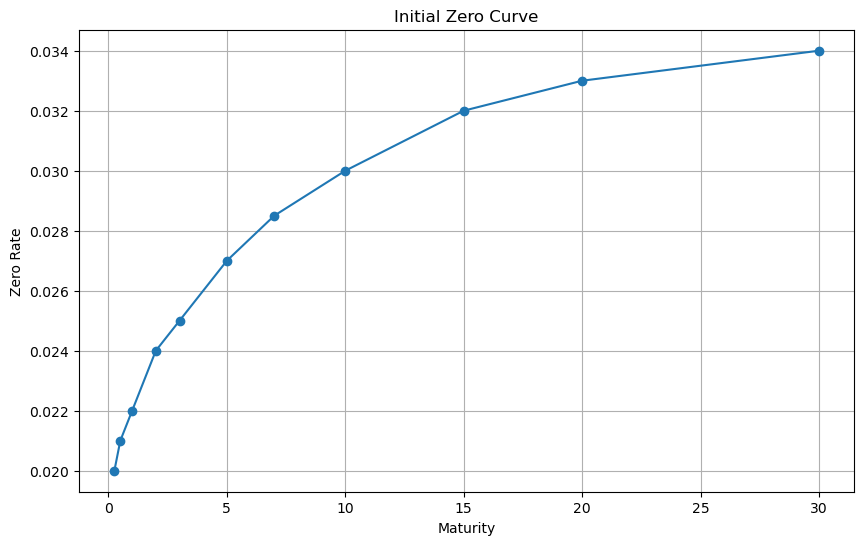

In [9]:
# ============================================================
# Plot Initial Zero Curve
# ============================================================

plt.figure()

plt.plot(
    curve_df["time"],
    curve_df["zero_rate"],
    marker="o"
)

plt.title("Initial Zero Curve")
plt.xlabel("Maturity")
plt.ylabel("Zero Rate")
plt.grid()
plt.show()

---
# 4. Hull-White Model Setup

The Hull-White model is:

$$
dr_t = \left(\theta(t) - a r_t \right)dt + \sigma dW_t
$$

We choose:

```text
a = 0.05
σ = 1%
```

as a baseline example.

The mean reversion parameter $a$ controls how quickly the short rate is pulled back toward its time-dependent mean level.

The volatility parameter $\sigma$ controls the randomness of short-rate paths.

In [11]:
# ============================================================
# Create Hull-White Model
# ============================================================

mean_reversion = 0.05
volatility = 0.01

model = HullWhiteModel(
    mean_reversion=mean_reversion,
    volatility=volatility,
    curve=curve
)

r0 = model.instantaneous_forward_rate(
    1e-6
)

print("Initial short rate proxy:", r0)
print("Mean reversion a:", mean_reversion)
print("Volatility sigma:", volatility)

Initial short rate proxy: 0.02000000000000102
Mean reversion a: 0.05
Volatility sigma: 0.01


---
# 5. The B(t,T) Function

Hull-White is an affine short-rate model.

Zero-coupon bond prices have the form:

$$
P(t,T) =
A(t,T)
\exp
\left(
-B(t,T)r_t
\right)
$$

where:

$$
B(t,T) =
\frac{
1 - e^{-a(T-t)}
}{a}
$$

The function $B(t,T)$ measures the sensitivity of a bond price to the short rate.

Longer maturities usually have larger $B(t,T)$, but mean reversion limits the sensitivity.

In [12]:
# ============================================================
# Inspect B(t,T)
# ============================================================

bond_maturities = np.array([1, 2, 3, 5, 7, 10, 20, 30])

B_values = [
    model.B(0.0, T)
    for T in bond_maturities
]

B_df = pd.DataFrame(
    {
        "maturity": bond_maturities,
        "B_0_T": B_values
    }
)

B_df

,maturity,B_0_T
0,1,0.975412
1,2,1.903252
2,3,2.785840
3,5,4.423984
4,7,5.906238
5,10,7.869387
6,20,12.642411
7,30,15.537397


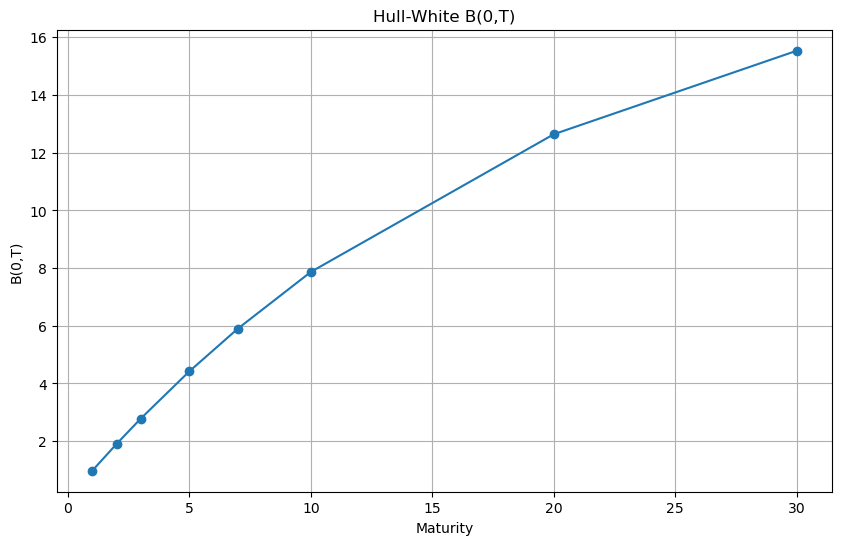

In [13]:
# ============================================================
# Plot B(0,T)
# ============================================================

plt.figure()

plt.plot(
    B_df["maturity"],
    B_df["B_0_T"],
    marker="o"
)

plt.title("Hull-White B(0,T)")
plt.xlabel("Maturity")
plt.ylabel("B(0,T)")
plt.grid()
plt.show()

---
# 6. The Drift Term θ(t)

The function $\theta(t)$ is chosen so that the Hull-White model fits the initial term structure.

For the model:

$$
dr_t = \left(\theta(t) -
a r_t
\right)dt
+
\sigma dW_t
$$

a commonly used expression is:

$$
\theta(t) =
\frac{\partial f(0,t)}{\partial t}
+
a f(0,t)
+
\frac{\sigma^2}{2a}
\left(
1-e^{-2at}
\right)
$$

where $f(0,t)$ is the instantaneous forward rate.


## Numerical Note

Because the input curve is discrete and interpolated, numerical derivatives of $f(0,t)$ can be noisy.

For this reason, the implementation uses finite differences with a practical bump size rather than an extremely small bump.

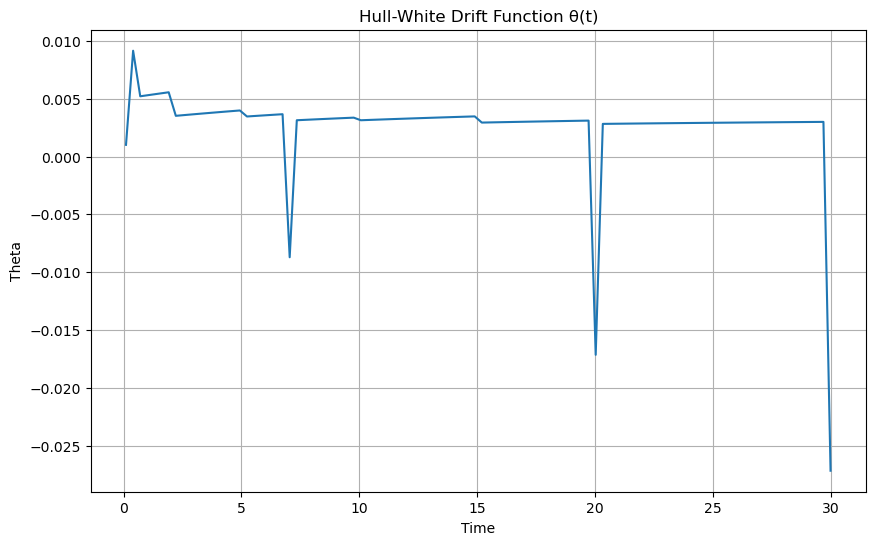

In [14]:
# ============================================================
# Plot theta(t)
# ============================================================

theta_times = np.linspace(0.1, 30.0, 100)

theta_values = [
    model.theta(t)
    for t in theta_times
]

plt.figure()

plt.plot(
    theta_times,
    theta_values
)

plt.title("Hull-White Drift Function θ(t)")
plt.xlabel("Time")
plt.ylabel("Theta")
plt.grid()
plt.show()

---
# 7. Initial Curve Fit

One of the most important properties of the Hull-White model is that it can fit the initial discount curve exactly.

At time zero:

$$
P_{HW}(0,T) =
P_{market}(0,T)
$$

The affine bond pricing formula is:

$$
P(t,T) =
A(t,T)
\exp
\left(
-B(t,T)r_t
\right)
$$

The function $A(t,T)$ is constructed from the initial discount curve so that the model is arbitrage-free with respect to today's curve.

In this section, we check whether model discount factors match market discount factors at \(t=0\).

In [15]:
# ============================================================
# Check Initial Curve Fit
# ============================================================

fit_maturities = np.array([
    0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30
])

fit_df = check_initial_curve_fit(
    model,
    fit_maturities
)

fit_df

,maturity,market_df,model_df,difference
0,0.5,0.989555,0.989555,4.440892e-16
1,1.0,0.978240,0.978240,1.110223e-15
2,2.0,0.953134,0.953134,1.998401e-15
3,3.0,0.927743,0.927743,2.775558e-15
4,5.0,0.873716,0.873716,4.329870e-15
5,7.0,0.819140,0.819140,5.329071e-15
6,10.0,0.740818,0.740818,6.439294e-15
7,15.0,0.618783,0.618783,7.216450e-15
8,20.0,0.516851,0.516851,7.216450e-15
9,30.0,0.360595,0.360595,6.161738e-15


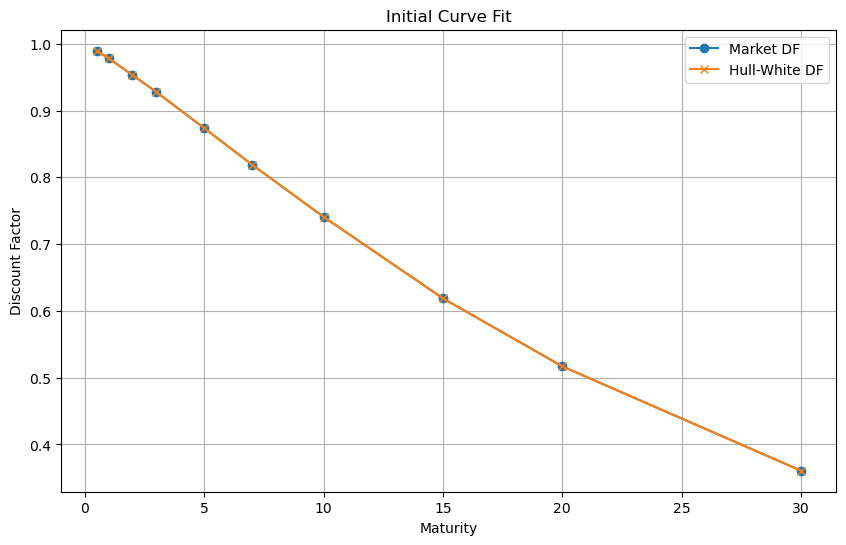

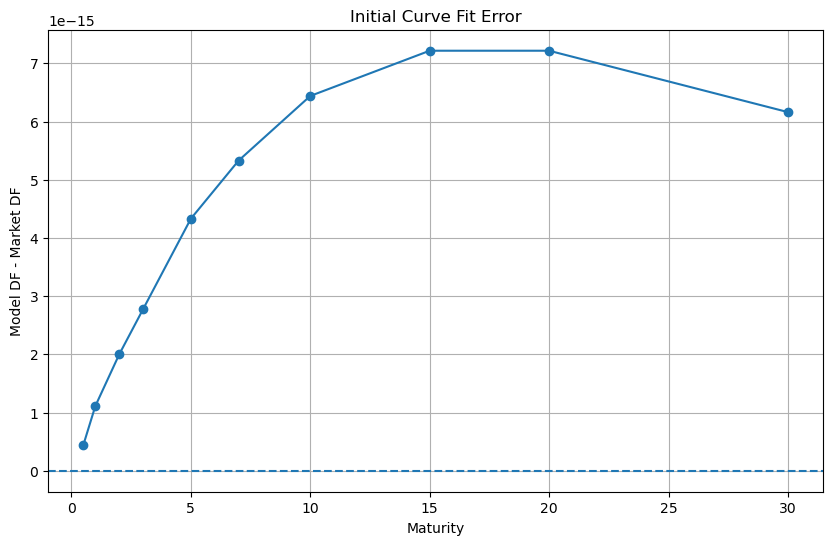

Curve Fit Summary
   maturity  market_df  model_df    difference
0       0.5   0.989555  0.989555  4.440892e-16
1       1.0   0.978240  0.978240  1.110223e-15
2       2.0   0.953134  0.953134  1.998401e-15
3       3.0   0.927743  0.927743  2.775558e-15
4       5.0   0.873716  0.873716  4.329870e-15
5       7.0   0.819140  0.819140  5.329071e-15
6      10.0   0.740818  0.740818  6.439294e-15
7      15.0   0.618783  0.618783  7.216450e-15
8      20.0   0.516851  0.516851  7.216450e-15
9      30.0   0.360595  0.360595  6.161738e-15

Max absolute error:
7.216449660063518e-15


In [16]:
# ============================================================
# Plot Initial Curve Fit
# ============================================================

plot_curve_fit(
    fit_df
)

plot_calibration_errors(
    fit_df
)

summarize_curve_fit(
    fit_df
)

---
# 8. Simulating Short-Rate Paths

We simulate short-rate paths using Euler discretisation:

$$
r_{t+\Delta t} = r_t + \left(\theta(t) -
a r_t
\right)
\Delta t
+
\sigma
\sqrt{\Delta t}
Z
$$

where:

$$
Z \sim N(0,1)
$$

This gives us a Monte Carlo representation of future interest-rate scenarios.

In [17]:
# ============================================================
# Simulate Hull-White Short-Rate Paths
# ============================================================

maturity = 10.0
n_steps = 240
n_paths = 2000

times_sim, short_rate_paths = simulate_short_rate_paths(
    model=model,
    r0=r0,
    maturity=maturity,
    n_steps=n_steps,
    n_paths=n_paths,
    seed=42
)

print("Simulation shape:", short_rate_paths.shape)

Simulation shape: (2000, 241)


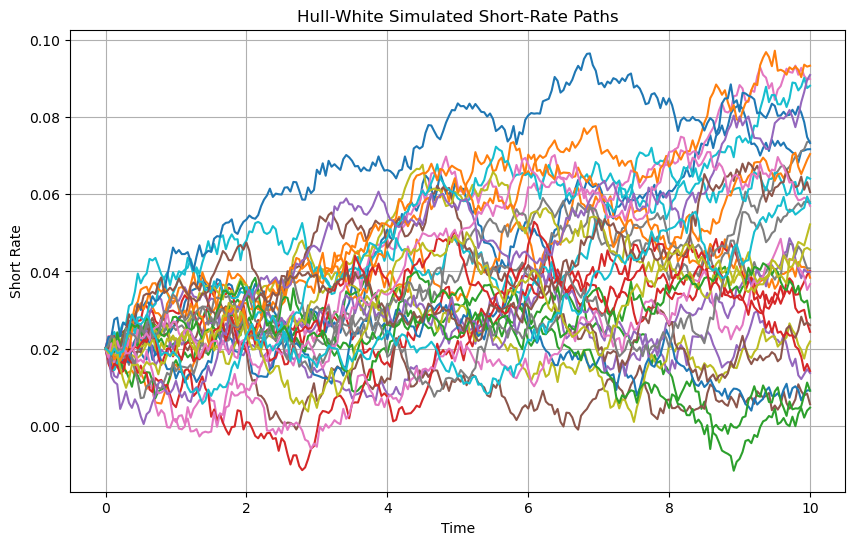

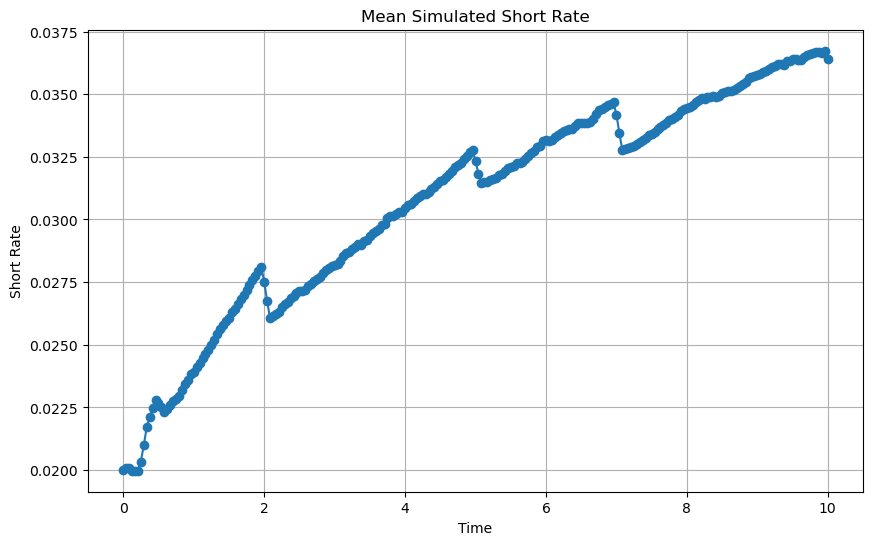

Short-Rate Path Summary
Initial rate: 0.020000
Final mean  : 0.036408
Final std   : 0.025421
Final min   : -0.041735
Final max   : 0.106066


In [18]:
# ============================================================
# Plot Simulated Short-Rate Paths
# ============================================================

plot_short_rate_paths(
    times_sim,
    short_rate_paths,
    n_plot=30
)

plot_mean_short_rate(
    times_sim,
    short_rate_paths
)

summarize_paths(
    times_sim,
    short_rate_paths
)

---
# 9. Monte Carlo Discount Factors

Given a short-rate path, the pathwise discount factor is:

$$
D(0,T) = \exp \left(-
\int_0^T r_t dt
\right)
$$

In simulation, the integral is approximated by a time-step sum.

The Monte Carlo zero-coupon bond price is:

$$
P(0,T)
\approx
\frac{1}{N}
\sum_{i=1}^{N}
D_i(0,T)
$$

This provides a useful consistency check against the market discount curve.

In [20]:
# ============================================================
# Monte Carlo Zero-Coupon Bond Price
# ============================================================

mc_df_10y = monte_carlo_zero_coupon_bond_price(
    times_sim,
    short_rate_paths
)

market_df_10y = curve.discount_factor(
    maturity
)

print("Market DF 10Y:", market_df_10y)
print("MC DF 10Y    :", mc_df_10y)
print("Difference  :", mc_df_10y - market_df_10y)

Market DF 10Y: 0.7408182206817179
MC DF 10Y    : 0.7446772265302657
Difference  : 0.003859005848547814


---
# 10. Zero-Coupon Bond Pricing

Under Hull-White, the zero-coupon bond price is available in closed form:

$$
P(t,T) =
A(t,T)
\exp
\left(
-B(t,T)r_t
\right)
$$

This affine form is one reason the Hull-White model is widely used.

It allows efficient pricing of bonds, bond options and interest-rate derivatives.

In [23]:
# ============================================================
# Example Zero-Coupon Bond Price at Future Time
# ============================================================

t = 0.0
T = 10.0
r_t = 0.02

bond_price = zero_coupon_bond_price(
    model=model,
    t=t,
    T=T,
    r_t=r_t
)

print(f"P({t},{T}) =", bond_price)

P(0.0,10.0) = 0.7408182206817303


---
# 11. Zero-Coupon Bond Option

A European call option on a zero-coupon bond has payoff:

$$
\max(P(\tau,T)-K,0)
$$

where:

- $\tau$ is the option expiry
- $T$ is the bond maturity
- $K$ is the bond option strike

Hull-White provides an analytic formula for this product.

This is useful because more complex rates products can often be decomposed into bond-option-like components.

## 11.1 Analytic Bond Option Price

In [24]:
# ============================================================

option_expiry = 2.0
bond_maturity = 10.0
strike = 0.75

analytic_option_price = price_zero_coupon_bond_option(
    model=model,
    option_expiry=option_expiry,
    bond_maturity=bond_maturity,
    strike=strike,
    option_type="call"
)

print("Analytic bond option price:", analytic_option_price)

Analytic bond option price: 0.04080451537517815


## 11.2 Monte Carlo Bond Option Price

In [25]:
# ============================================================

# Simulate paths up to the option expiry.
times_option, paths_option = simulate_short_rate_paths(
    model=model,
    r0=r0,
    maturity=option_expiry,
    n_steps=120,
    n_paths=10000,
    seed=123
)

mc_option_price = monte_carlo_bond_option_price(
    model=model,
    times=times_option,
    short_rate_paths=paths_option,
    option_expiry=option_expiry,
    bond_maturity=bond_maturity,
    strike=strike,
    option_type="call"
)

compare_prices(
    analytic_option_price,
    mc_option_price
)

Pricing Comparison
Analytic price    : 0.04080452
Monte Carlo price : 0.03976451
Difference        : -0.00104001


---
# 12. Calibration Example

In practice, Hull-White parameters are often calibrated to swaption prices or caps/floors.

In this simplified chapter, we calibrate:

$$
a
$$

and

$$
\sigma
$$

to a small set of synthetic bond option prices.

This demonstrates the general calibration workflow:

```text
Choose model parameters
        ↓
Price calibration instruments
        ↓
Compare with market prices
        ↓
Minimize pricing errors
```

A production system would typically calibrate the Hull-White model to a swaption volatility surface.

## 12.1 Create Synthetic Calibration Instruments

In [26]:
# ============================================================
true_model = HullWhiteModel(
    mean_reversion=0.08,
    volatility=0.012,
    curve=curve
)

option_data = []

for tau, T, K in [
    (1.0, 5.0, 0.82),
    (2.0, 7.0, 0.75),
    (3.0, 10.0, 0.65)
]:

    market_price = price_zero_coupon_bond_option(
        model=true_model,
        option_expiry=tau,
        bond_maturity=T,
        strike=K,
        option_type="call"
    )

    option_data.append(
        {
            "option_expiry": tau,
            "bond_maturity": T,
            "strike": K,
            "market_price": market_price,
            "option_type": "call"
        }
    )

option_data

[{'option_expiry': 1.0,
  'bond_maturity': 5.0,
  'strike': 0.82,
  'market_price': np.float64(0.07173778818154708),
  'option_type': 'call'},
 {'option_expiry': 2.0,
  'bond_maturity': 7.0,
  'strike': 0.75,
  'market_price': np.float64(0.10460563684865676),
  'option_type': 'call'},
 {'option_expiry': 3.0,
  'bond_maturity': 10.0,
  'strike': 0.65,
  'market_price': np.float64(0.13824713254607968),
  'option_type': 'call'}]

## 12.2 Calibrate Hull-White Parameters

In [27]:
# ============================================================

calibration_result = calibrate_hull_white(
    curve=curve,
    option_data=option_data,
    model_class=HullWhiteModel,
    initial_guess=(0.05, 0.01)
)

calibration_result

{'mean_reversion': np.float64(0.04997883737792237),
 'volatility': np.float64(0.010625976894438702),
 'objective': np.float64(8.197461105179273e-09),
 'success': True,
 'message': 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH'}

## 12.3. Interpretation of Calibration

The calibration attempts to recover the parameters used to generate the synthetic option prices.

The true parameters were:

```text
a     = 0.08
sigma = 0.012
```

The calibrated result should be reasonably close, although exact recovery depends on:

- number of calibration instruments
- option maturities
- strikes
- optimizer tolerance
- numerical approximations

In real markets, calibration errors also reflect bid-ask spreads, instrument liquidity and model misspecification.

---
# 13. Chapter Summary

In this chapter we implemented:

- one-factor Hull-White short-rate dynamics
- curve-consistent drift function \(\theta(t)\)
- affine bond pricing
- short-rate Monte Carlo simulation
- pathwise discounting
- zero-coupon bond option pricing
- simple calibration to synthetic option prices

## 13.1 Key Lessons

1. Hull-White is a mean-reverting short-rate model.
2. The drift term \(\theta(t)\) fits the initial yield curve.
3. Zero-coupon bond prices are affine in the short rate.
4. Monte Carlo paths can be used to compute discount factors.
5. Bond options have analytic prices under Hull-White.
6. Calibration matches model prices to market instruments.

## 13.2 Quant Notes

The Hull-White model is widely used because it is simple and tractable.

### Strengths

- Fits the initial yield curve
- Allows negative rates
- Has analytical bond option formulas
- Supports trees and finite difference methods
- Useful for callable bonds and Bermudan swaptions

### Weaknesses

- One-factor structure limits curve-shape dynamics
- Constant volatility is too simple
- Cannot naturally generate volatility smiles
- Correlation structure is restrictive

This motivates Chapter 10, where short-rate models are extended with stochastic volatility.


## 13.3 Next Chapter

### Chapter 10: Short Rate Models with Stochastic Volatility

We will extend the Hull-White framework by allowing volatility itself to become stochastic.

Topics include:

- stochastic volatility state variables
- short-rate and volatility joint dynamics
- Monte Carlo simulation
- comparison with constant-volatility Hull-White
- implications for smile and skew modelling